# QQQ Volatility Forecasting: Data Loading, Validation and Cleaning

Notebook นี้อธิบายข้อมูลรายวันของ QQQ ตั้งแต่ข้อมูลดิบจนถึง clean artifact เพื่อใช้เป็นหลักฐานประกอบ Presentation โดยถือว่าข้อมูลเป็น time series และใช้ `Close` เป็นราคาหลักเท่านั้น ไม่มีการใช้ `Adj Close`

Logic การทำความสะอาดยังคงอยู่ใน `src/clean_data.py`; Notebook นี้อ่านและตรวจสอบ artifacts ที่ pipeline สร้างไว้แล้วเท่านั้น

## 1. Project and Notebook Objective

ตรวจสอบโครงสร้างข้อมูล ปัญหาคุณภาพ กฎที่ implementation ใช้ และความสมบูรณ์ของ clean artifact โดยไม่แก้ไข source data หรือ reports

## 2. Environment and Imports

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

current = Path.cwd().resolve()
project_root = current.parent if current.name == "notebooks" else current
if not (project_root / "config.py").is_file() or not (project_root / "src").is_dir():
    raise FileNotFoundError(
        f"Could not resolve project root from {current}; expected config.py and src/."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

figure_dir = project_root / "outputs" / "figures" / "data_preparation"
figure_dir.mkdir(parents=True, exist_ok=True)

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as source_file:
        for chunk in iter(lambda: source_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest().upper()

def require_files(paths: dict[str, Path]) -> None:
    missing = [f"{name}: {path}" for name, path in paths.items() if not path.is_file()]
    if missing:
        raise FileNotFoundError("Missing required pipeline artifacts:\n" + "\n".join(missing))

def reject_adjusted_close(df: pd.DataFrame, dataset_name: str) -> None:
    forbidden = sorted({"Adj Close", "adj_close", "Adjusted Close"}.intersection(df.columns))
    if forbidden:
        raise ValueError(f"{dataset_name} contains forbidden columns: {forbidden}")

from config import CLEAN_DATA_PATH, CLEANING_REPORT_PATH, RAW_DATA_PATH
from src.load_data import REQUIRED_COLUMNS

input_sources = {
    "raw_data": Path(RAW_DATA_PATH),
    "clean_data": Path(CLEAN_DATA_PATH),
    "cleaning_report": Path(CLEANING_REPORT_PATH),
}
require_files(input_sources)
checksums_before = {name: sha256(path) for name, path in input_sources.items()}
display(pd.DataFrame.from_dict(checksums_before, orient="index", columns=["SHA-256 before"]))

mkdir -p failed for path C:\Users\ADMIN\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\ADMIN\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\ADMIN\AppData\Local\Temp\matplotlib-kfnvvi2u because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,SHA-256 before
raw_data,649E1DB1B79C0990EA947A4EA162D6836B9BBDDA2AF24B...
clean_data,062A7A57A55F0336F257B0CAE3425CB67E0DA0C30C4185...
cleaning_report,300BF924316EE269E4683E2DAD6E1A566405401150F940...


## 3. Load Raw and Clean Data

วันที่ถูก parse แบบ strict ด้วย `errors='raise'`; หาก artifact ผิดรูปแบบ Notebook จะหยุดทันที

In [2]:
raw_df = pd.read_csv(input_sources["raw_data"])
clean_df = pd.read_csv(input_sources["clean_data"])
raw_df["Date"] = pd.to_datetime(raw_df["Date"], errors="raise")
clean_df["Date"] = pd.to_datetime(clean_df["Date"], errors="raise")

for name, frame in {"raw": raw_df, "clean": clean_df}.items():
    missing_required = [column for column in REQUIRED_COLUMNS if column not in frame.columns]
    if missing_required:
        raise ValueError(f"{name} data is missing required columns: {missing_required}")
    reject_adjusted_close(frame, name)

with input_sources["cleaning_report"].open("r", encoding="utf-8") as report_file:
    cleaning_report = json.load(report_file)

print(f"Raw shape:   {raw_df.shape}")
print(f"Clean shape: {clean_df.shape}")
print(f"Cleaning report keys: {sorted(cleaning_report)}")

Raw shape:   (2512, 6)
Clean shape: (2512, 6)
Cleaning report keys: ['date_max_after', 'date_max_before', 'date_min_after', 'date_min_before', 'duplicate_date_rows', 'exact_duplicate_rows', 'high_below_low_rows', 'invalid_date_rows', 'missing_values_after', 'missing_values_before', 'negative_volume_rows', 'nonpositive_price_rows', 'numeric_values_coerced', 'open_outside_range_rows', 'rows_after', 'rows_before', 'rows_removed', 'rows_removed_for_missing_required_values', 'zero_volume_rows_preserved']


## 4. Raw Dataset Overview

In [3]:
def infinity_counts(df: pd.DataFrame) -> pd.Series:
    numeric = df.select_dtypes(include=[np.number])
    return pd.Series(
        {column: int(np.isinf(numeric[column].to_numpy(dtype=float)).sum()) for column in numeric},
        name="infinity_count",
        dtype="int64",
    )

raw_overview = pd.Series({
    "rows": len(raw_df),
    "columns": raw_df.shape[1],
    "start_date": raw_df["Date"].min().strftime("%Y-%m-%d"),
    "end_date": raw_df["Date"].max().strftime("%Y-%m-%d"),
    "duplicate_dates": int(raw_df["Date"].duplicated().sum()),
    "rows_with_missing": int(raw_df.isna().any(axis=1).sum()),
    "total_missing_cells": int(raw_df.isna().sum().sum()),
    "rows_with_infinity": int(np.isinf(raw_df.select_dtypes(include=[np.number])).any(axis=1).sum()),
})
display(raw_overview.to_frame("Raw dataset"))
display(pd.DataFrame({"dtype": raw_df.dtypes.astype(str), "missing": raw_df.isna().sum()}))
display(infinity_counts(raw_df).to_frame())
display(raw_df.head(5))
display(raw_df.tail(5))

,Raw dataset
rows,2512
columns,6
start_date,2016-08-31
end_date,2026-08-28
duplicate_dates,0
rows_with_missing,0
total_missing_cells,0
rows_with_infinity,0


,dtype,missing
Date,datetime64[us],0
Close,float64,0
Volume,int64,0
Open,float64,0
High,float64,0
Low,float64,0


,infinity_count
Close,0
Volume,0
Open,0
High,0
Low,0


,Date,Close,Volume,Open,High,Low
0,2026-08-28,716.43,34105370,719.74,724.125,715.085
1,2026-08-27,721.11,28723450,716.93,721.350,714.525
2,2026-08-26,711.37,20392390,708.41,713.020,707.970
3,2026-08-25,710.72,23869650,711.22,714.040,707.450
4,2026-08-24,706.32,37443140,709.66,709.790,702.700


,Date,Close,Volume,Open,High,Low
2507,2016-09-07,117.92,17532760,117.95,118.12,117.47
2508,2016-09-06,117.85,18502030,117.29,117.85,117.06
2509,2016-09-02,117.12,18082250,117.32,117.56,116.68
2510,2016-09-01,116.74,20936680,116.48,116.88,115.91
2511,2016-08-31,116.44,16068760,116.38,116.56,115.95


## 5. Cleaning Rules Implemented in `src/clean_data.py`

- ตรวจ required columns ก่อนทำงาน และทำงานบน deep copy
- Parse `Date` ด้วย `errors="coerce"` แล้วลบ invalid dates
- แปลง `Open`, `High`, `Low`, `Close`, `Volume` เป็น numeric และรายงานค่าที่ถูก coerce
- ลบ exact duplicates และรวม duplicate dates ที่ OHLCV เหมือนกัน; หาก OHLCV ขัดแย้งกันจะ raise error
- ลบ missing values เฉพาะ required columns
- ลบราคาที่ไม่เป็นบวก, `High < Low`, `Open` นอกช่วง Low–High และ Volume ติดลบ
- เก็บ Volume เท่ากับศูนย์ และไม่ลบ extreme market moves ด้วย Z-score/IQR
- เรียงวันที่จากอดีตไปอนาคตและ reset index

**Infinity note:** Cleaning implementation ปัจจุบันไม่มี explicit rule สำหรับลบหรือแทน Infinity ส่วน Notebook นี้ตรวจนับ Infinity ที่พบจริง และ explicit Infinity handling จะเกิดใน Modeling Data Preparation ภายหลัง

## 6. Before and After Cleaning Summary

In [4]:
def quality_metrics(df: pd.DataFrame) -> dict[str, object]:
    numeric = df.select_dtypes(include=[np.number])
    return {
        "Rows": len(df),
        "Columns": df.shape[1],
        "Start date": df["Date"].min().strftime("%Y-%m-%d"),
        "End date": df["Date"].max().strftime("%Y-%m-%d"),
        "Duplicate dates": int(df["Date"].duplicated().sum()),
        "Rows with missing": int(df.isna().any(axis=1).sum()),
        "Total missing cells": int(df.isna().sum().sum()),
        "Rows with infinity": int(np.isinf(numeric).any(axis=1).sum()),
    }

raw_metrics = quality_metrics(raw_df)
clean_metrics = quality_metrics(clean_df)
summary = pd.DataFrame({"Raw": raw_metrics, "Clean": clean_metrics})
summary["Difference"] = [
    clean_metrics[key] - raw_metrics[key]
    if isinstance(raw_metrics[key], (int, np.integer)) else "—"
    for key in summary.index
]
display(summary)

category_keys = [
    "invalid_date_rows", "exact_duplicate_rows", "duplicate_date_rows",
    "rows_removed_for_missing_required_values", "nonpositive_price_rows",
    "high_below_low_rows", "open_outside_range_rows", "negative_volume_rows",
    "zero_volume_rows_preserved",
]
category_counts = pd.Series(
    {key: cleaning_report.get(key) for key in category_keys},
    name="reported_count",
)
display(Markdown(f"**Rows actually removed:** `{cleaning_report['rows_removed']}`"))
display(category_counts.to_frame())
display(Markdown("Category counts อาจ overlap กันได้ จึงไม่ถูกนำมาบวกเพื่อหา total rows removed"))

,Raw,Clean,Difference
Rows,2512,2512,0
Columns,6,6,0
Start date,2016-08-31,2016-08-31,—
End date,2026-08-28,2026-08-28,—
Duplicate dates,0,0,0
Rows with missing,0,0,0
Total missing cells,0,0,0
Rows with infinity,0,0,0


**Rows actually removed:** `0`

,reported_count
invalid_date_rows,0
exact_duplicate_rows,0
duplicate_date_rows,0
rows_removed_for_missing_required_values,0
nonpositive_price_rows,0
high_below_low_rows,0
open_outside_range_rows,0
negative_volume_rows,0
zero_volume_rows_preserved,0


Category counts อาจ overlap กันได้ จึงไม่ถูกนำมาบวกเพื่อหา total rows removed

## 7. Missing Values Visualization

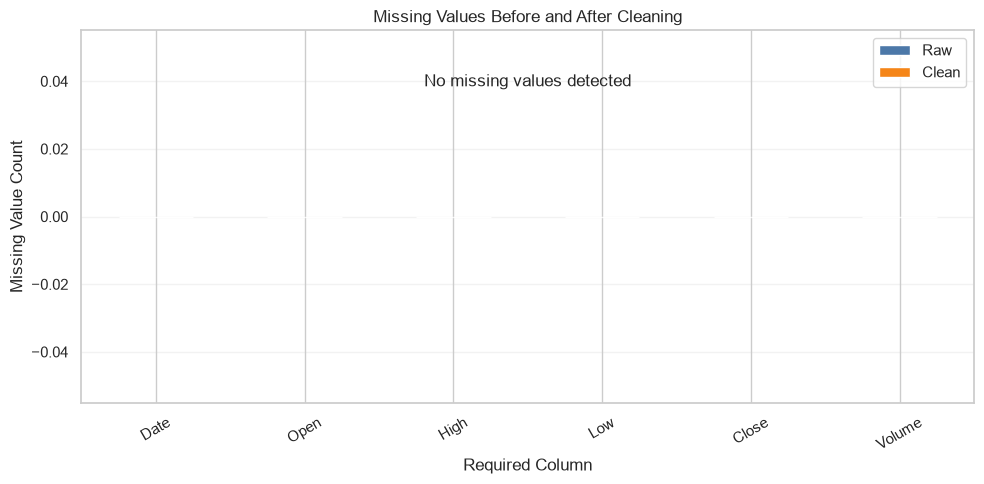

,Raw,Clean
Date,0,0
Open,0,0
High,0,0
Low,0,0
Close,0,0
Volume,0,0


In [5]:
missing_comparison = pd.DataFrame({
    "Raw": raw_df[REQUIRED_COLUMNS].isna().sum(),
    "Clean": clean_df[REQUIRED_COLUMNS].isna().sum(),
})
ax = missing_comparison.plot(kind="bar", figsize=(10, 5), color=["#4C78A8", "#F58518"])
fig = ax.figure
ax.set_title("Missing Values Before and After Cleaning")
ax.set_xlabel("Required Column")
ax.set_ylabel("Missing Value Count")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)
if int(missing_comparison.to_numpy().sum()) == 0:
    ax.text(0.5, 0.85, "No missing values detected", transform=ax.transAxes, ha="center")
fig.tight_layout()
output_path = figure_dir / "01_missing_values_before_after.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
display(missing_comparison)

## 8. Raw vs Clean Sample

In [6]:
display(Markdown("### Raw sample (first and last 3 rows)"))
display(pd.concat([raw_df.head(3), raw_df.tail(3)]))
display(Markdown("### Clean sample (first and last 3 rows)"))
display(pd.concat([clean_df.head(3), clean_df.tail(3)]))

### Raw sample (first and last 3 rows)

,Date,Close,Volume,Open,High,Low
0,2026-08-28,716.43,34105370,719.74,724.125,715.085
1,2026-08-27,721.11,28723450,716.93,721.350,714.525
2,2026-08-26,711.37,20392390,708.41,713.020,707.970
2509,2016-09-02,117.12,18082250,117.32,117.560,116.680
2510,2016-09-01,116.74,20936680,116.48,116.880,115.910
2511,2016-08-31,116.44,16068760,116.38,116.560,115.950


### Clean sample (first and last 3 rows)

,Date,Close,Volume,Open,High,Low
0,2016-08-31,116.44,16068760,116.38,116.560,115.950
1,2016-09-01,116.74,20936680,116.48,116.880,115.910
2,2016-09-02,117.12,18082250,117.32,117.560,116.680
2509,2026-08-26,711.37,20392390,708.41,713.020,707.970
2510,2026-08-27,721.11,28723450,716.93,721.350,714.525
2511,2026-08-28,716.43,34105370,719.74,724.125,715.085


## 9. Data Integrity Validation

In [7]:
assert pd.api.types.is_datetime64_any_dtype(clean_df["Date"])
assert not clean_df["Date"].duplicated().any()
assert clean_df["Date"].is_monotonic_increasing
assert all(column in clean_df.columns for column in REQUIRED_COLUMNS)
assert "Close" in clean_df.columns
reject_adjusted_close(clean_df, "clean")
assert not clean_df[REQUIRED_COLUMNS].isna().any().any()
clean_numeric = clean_df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=float)
assert not np.isinf(clean_numeric).any(), "Current clean artifact contains Infinity"
assert (clean_df[["Open", "High", "Low", "Close"]] > 0).all(axis=None)
assert (clean_df["High"] >= clean_df["Low"]).all()
assert ((clean_df["Open"] >= clean_df["Low"]) & (clean_df["Open"] <= clean_df["High"])).all()
assert (clean_df["Volume"] >= 0).all()
print("All clean-artifact integrity assertions passed.")

All clean-artifact integrity assertions passed.


## 10. Cleaning Conclusion

In [8]:
display(Markdown(
    f"""
ข้อมูลจริงมี **{cleaning_report['rows_before']:,}** แถวก่อน cleaning และเหลือ
**{cleaning_report['rows_after']:,}** แถวหลัง cleaning โดยลบจริง
**{cleaning_report['rows_removed']:,}** แถว ช่วงข้อมูลสะอาดคือ
**{clean_df['Date'].min():%Y-%m-%d} ถึง {clean_df['Date'].max():%Y-%m-%d}**

ผลการตรวจ artifact ปัจจุบันยืนยันว่า required columns ครบ, Date ไม่ซ้ำและเรียงเวลา,
ไม่มี missing หรือ Infinity ใน required numeric columns และพร้อมเข้าสู่ Feature Engineering
"""
))


ข้อมูลจริงมี **2,512** แถวก่อน cleaning และเหลือ
**2,512** แถวหลัง cleaning โดยลบจริง
**0** แถว ช่วงข้อมูลสะอาดคือ
**2016-08-31 ถึง 2026-08-28**

ผลการตรวจ artifact ปัจจุบันยืนยันว่า required columns ครบ, Date ไม่ซ้ำและเรียงเวลา,
ไม่มี missing หรือ Infinity ใน required numeric columns และพร้อมเข้าสู่ Feature Engineering


## Source Integrity Check

In [9]:
checksums_after = {name: sha256(path) for name, path in input_sources.items()}
checksum_audit = pd.DataFrame({
    "before": checksums_before,
    "after": checksums_after,
})
checksum_audit["unchanged"] = checksum_audit["before"] == checksum_audit["after"]
display(checksum_audit)
if not checksum_audit["unchanged"].all():
    changed = checksum_audit.index[~checksum_audit["unchanged"]].tolist()
    raise RuntimeError(f"Notebook changed input sources: {changed}")
print("All Notebook 1 input checksums are unchanged.")

,before,after,unchanged
raw_data,649E1DB1B79C0990EA947A4EA162D6836B9BBDDA2AF24B...,649E1DB1B79C0990EA947A4EA162D6836B9BBDDA2AF24B...,True
clean_data,062A7A57A55F0336F257B0CAE3425CB67E0DA0C30C4185...,062A7A57A55F0336F257B0CAE3425CB67E0DA0C30C4185...,True
cleaning_report,300BF924316EE269E4683E2DAD6E1A566405401150F940...,300BF924316EE269E4683E2DAD6E1A566405401150F940...,True


All Notebook 1 input checksums are unchanged.
